## Sweep Analysis

Visualises the results of parameter sweeps produced by `experiments/sweep.py`.

**Workflow:**
1. Run a sweep from the terminal, e.g.  
   `python -m experiments.sweep --param dropout --values 0 0.05 0.10 0.20 0.40 --no-myopic`
2. Come back here, run the *Setup* and *Load data* cells, then run the plot sections you need.

Each plot section is self-contained — skip sections whose sweep you haven't run yet.

### Setup

In [34]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path(r"C:\Users\49160\Adaptive-Onboarding")
sys.path.append(str(repo_root))

from src.plots import (
    ACTIVE_BLACK, PALETTE, POSTERIOR_GREEN, PRIOR_BLUE,
    QUESTION_ORANGE, STRUCTURE_GRAY,
    apply_notebook_style, save, style_ax,
)

apply_notebook_style()

RESULTS_DIR = repo_root / "experiments" / "results"

# Consistent style per policy — used in every plot
POLICY_STYLE: dict[str, dict] = {
    "fixed":               {"color": STRUCTURE_GRAY,  "ls": "--", "marker": "s", "label": "Fixed"},
    "random":              {"color": PRIOR_BLUE,       "ls": "--", "marker": "^", "label": "Random"},
    "myopic_exact":        {"color": ACTIVE_BLACK,     "ls": "-",  "marker": "D", "label": "Myopic (exact)"},
    "surrogate_unweighted":{"color": QUESTION_ORANGE,  "ls": "-",  "marker": "o", "label": "Surrogate (unweighted)"},
    "surrogate_weighted":  {"color": POSTERIOR_GREEN,  "ls": "-",  "marker": "o", "label": "Surrogate (weighted)"},
}

print(f"Results directory: {RESULTS_DIR}")
print(f"Available files : {[f.name for f in sorted(RESULTS_DIR.glob('*.json'))]}")

Results directory: C:\Users\49160\Adaptive-Onboarding\experiments\results
Available files : ['20260428_164550_sweep_dropout.json', '20260428_164624_dim6_h20_p0_n500.json', '20260428_164654_dim6_h20_p1_n500.json', '20260428_164720_dim6_h20_p5_n500.json', '20260428_164749_dim2_h1_p10_n3.json', '20260428_164749_dim2_h2_p10_n3.json', '20260428_164749_sweep_horizon.json', '20260428_164750_dim6_h20_p10_n500.json', '20260428_164817_dim6_h20_p15_n500.json', '20260428_164837_dim6_h20_p20_n500.json', '20260428_164856_dim6_h20_p40_n500.json', '20260428_164858_sweep_sensitive_frac.json', '20260428_164931_dim6_h20_p10_n500.json', '20260428_165015_dim6_h20_p10_n500.json', '20260428_165043_dim6_h20_p10_n500.json', '20260428_165113_dim6_h20_p10_n500.json', '20260428_165150_dim6_h20_p10_n500.json']


### Load data

In [35]:
def load_sweep(param: str) -> dict:
    """
    Load the most recent sweep JSON for the given parameter name.
    E.g. load_sweep("dropout") finds the latest *sweep_dropout*.json.
    """
    pattern = f"*sweep_{param.replace('-', '_')}*.json"
    files = sorted(RESULTS_DIR.glob(pattern))
    if not files:
        raise FileNotFoundError(
            f"No sweep file found for param='{param}' in {RESULTS_DIR}.\n"
            f"Run: python -m experiments.sweep --param {param} --values ..."
        )
    path = files[-1]   # most recent
    print(f"Loading: {path.name}")
    return json.loads(path.read_text(encoding="utf-8"))


def load_run(pattern: str = "*.json") -> dict:
    """
    Load the most recent single-run JSON (not a sweep).
    Useful for sanity-checking a single condition.
    """
    files = [f for f in sorted(RESULTS_DIR.glob(pattern)) if "sweep" not in f.name]
    if not files:
        raise FileNotFoundError(f"No single-run JSON found matching '{pattern}'.")
    path = files[-1]
    print(f"Loading: {path.name}")
    return json.loads(path.read_text(encoding="utf-8"))


def sweep_series(data: dict, metric: str) -> dict[str, tuple[list, list]]:
    """
    Extract (sweep_values, metric_values) per policy from a sweep JSON.
    Returns {policy_name: (x_values, y_values)}.
    """
    series: dict[str, tuple[list, list]] = {}
    for condition in data["conditions"]:
        x = condition["value"]
        for policy, metrics in condition["policies"].items():
            if policy not in series:
                series[policy] = ([], [])
            series[policy][0].append(x)
            series[policy][1].append(metrics.get(metric, float("nan")))
    return series


print("Helpers ready.")

Helpers ready.


---
## 1 — Dropout probability sweep

**Run first:**
```bash
python -m experiments.sweep --param dropout --values 0 0.05 0.10 0.20 0.40 --no-myopic
# Add myopic for the final thesis run (slow):
python -m experiments.sweep --param dropout --values 0 0.05 0.10 0.20 0.40
```

In [36]:
dropout_sweep = load_sweep("dropout")

Loading: 20260428_164550_sweep_dropout.json


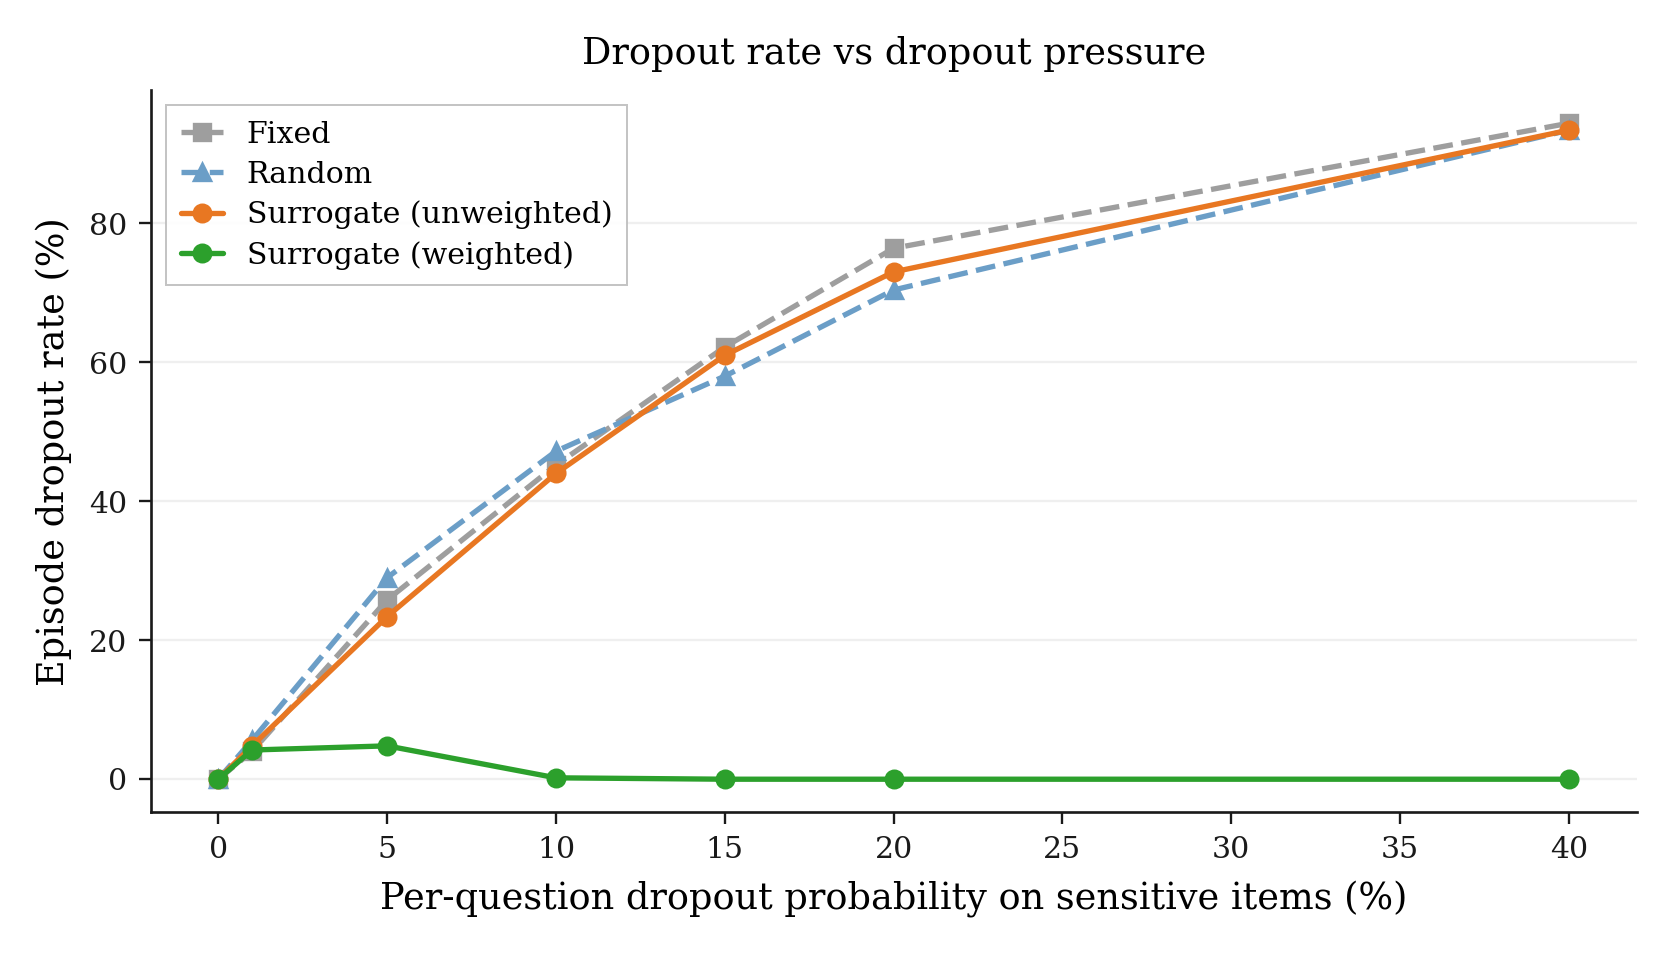

In [37]:
# ── Figure 1a: Dropout rate vs dropout probability ────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

series = sweep_series(dropout_sweep, "dropout_rate")
for policy, (xs, ys) in series.items():
    s = POLICY_STYLE[policy]
    ax.plot(np.array(xs) * 100, np.array(ys) * 100,
            color=s["color"], ls=s["ls"], marker=s["marker"],
            markersize=5, linewidth=1.6, label=s["label"])

ax.set_xlabel("Per-question dropout probability on sensitive items (%)")
ax.set_ylabel("Episode dropout rate (%)")
ax.set_title("Dropout rate vs dropout pressure")
style_ax(ax, grid_axis="y")
ax.legend()
plt.tight_layout()
# save(fig, "fig_dropout_rate_vs_pressure")  # uncomment to export
plt.show()

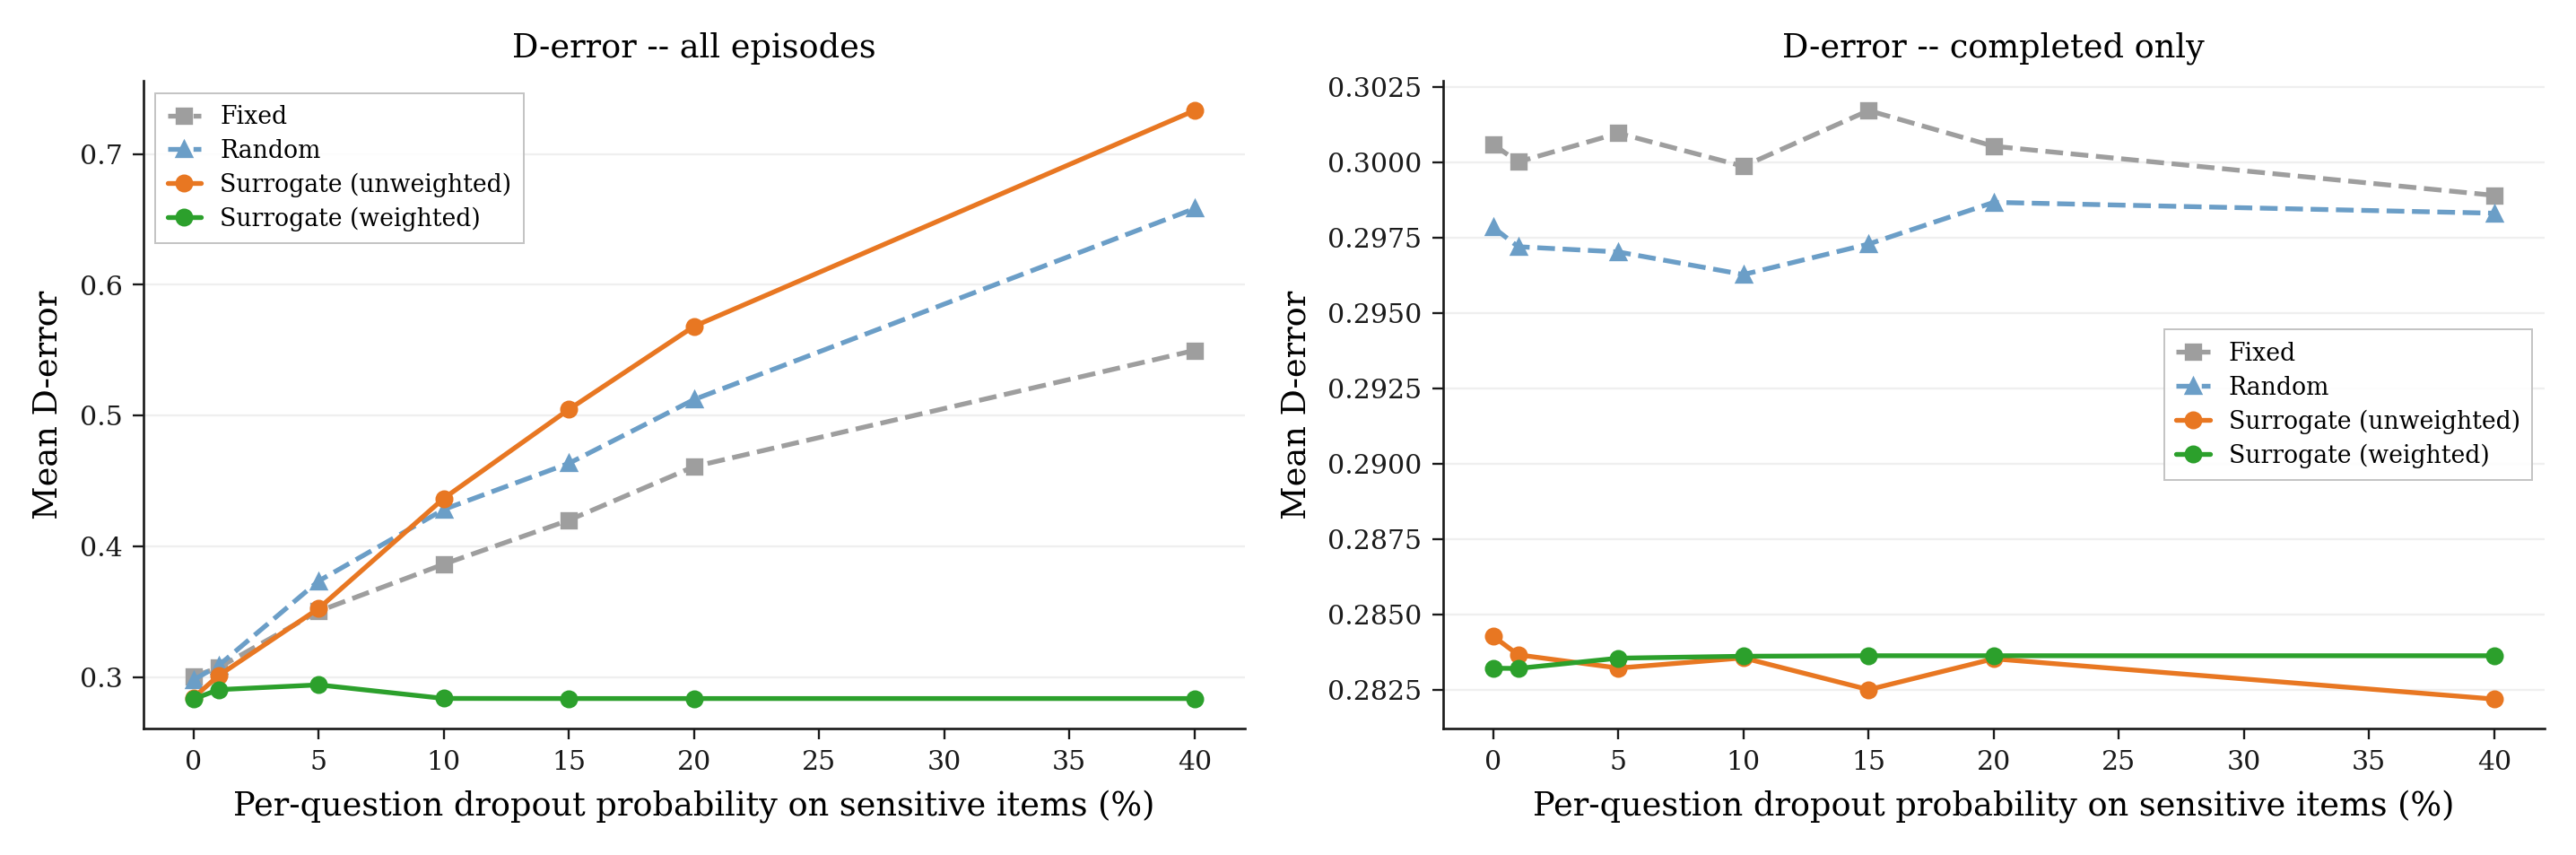

In [38]:
# Figure 1b: D-error vs dropout probability (all vs completed episodes)
# Left:  all episodes -- includes dropout episodes whose posteriors are less
#        refined because they ended early, inflating D-error for high-dropout policies.
# Right: completed episodes only -- isolates genuine information quality from truncation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], "mean_final_d_error",          "D-error -- all episodes"),
    (axes[1], "mean_final_d_error_completed",  "D-error -- completed only"),
]:
    series = sweep_series(dropout_sweep, metric)
    for policy, (xs, ys) in series.items():
        s = POLICY_STYLE[policy]
        ax.plot(np.array(xs) * 100, ys,
                color=s["color"], ls=s["ls"], marker=s["marker"],
                markersize=5, linewidth=1.6, label=s["label"])
    ax.set_xlabel("Per-question dropout probability on sensitive items (%)")
    ax.set_ylabel("Mean D-error")
    ax.set_title(title)
    style_ax(ax, grid_axis="y")
    ax.legend(fontsize=8)

plt.tight_layout()
# save(fig, "fig_d_error_vs_dropout")  # uncomment to export
plt.show()

The unweighted surrogate performing slightly better on those users that didn't drop out shows the fundamental trade-off faced by our sensitivity-aware policy.
- surrogate_unweighted selects whichever item maximises information gain, treating all items equally. It will ask sensitive items whenever they're informative.

- surrogate_weighted downweights sensitive items by their dropout risk before selecting. It deliberately sacrifices some information per question to reduce the probability of the user dropping out.

For users who happened to not drop out — the completed subset — surrogate_unweighted had been asking the most informative questions available, including sensitive ones. Those users' posteriors are therefore more refined. surrogate_weighted, by contrast, systematically avoided those same informative questions and substituted less informative non-sensitive ones. So for the users who stuck around regardless, weighted left information on the table.

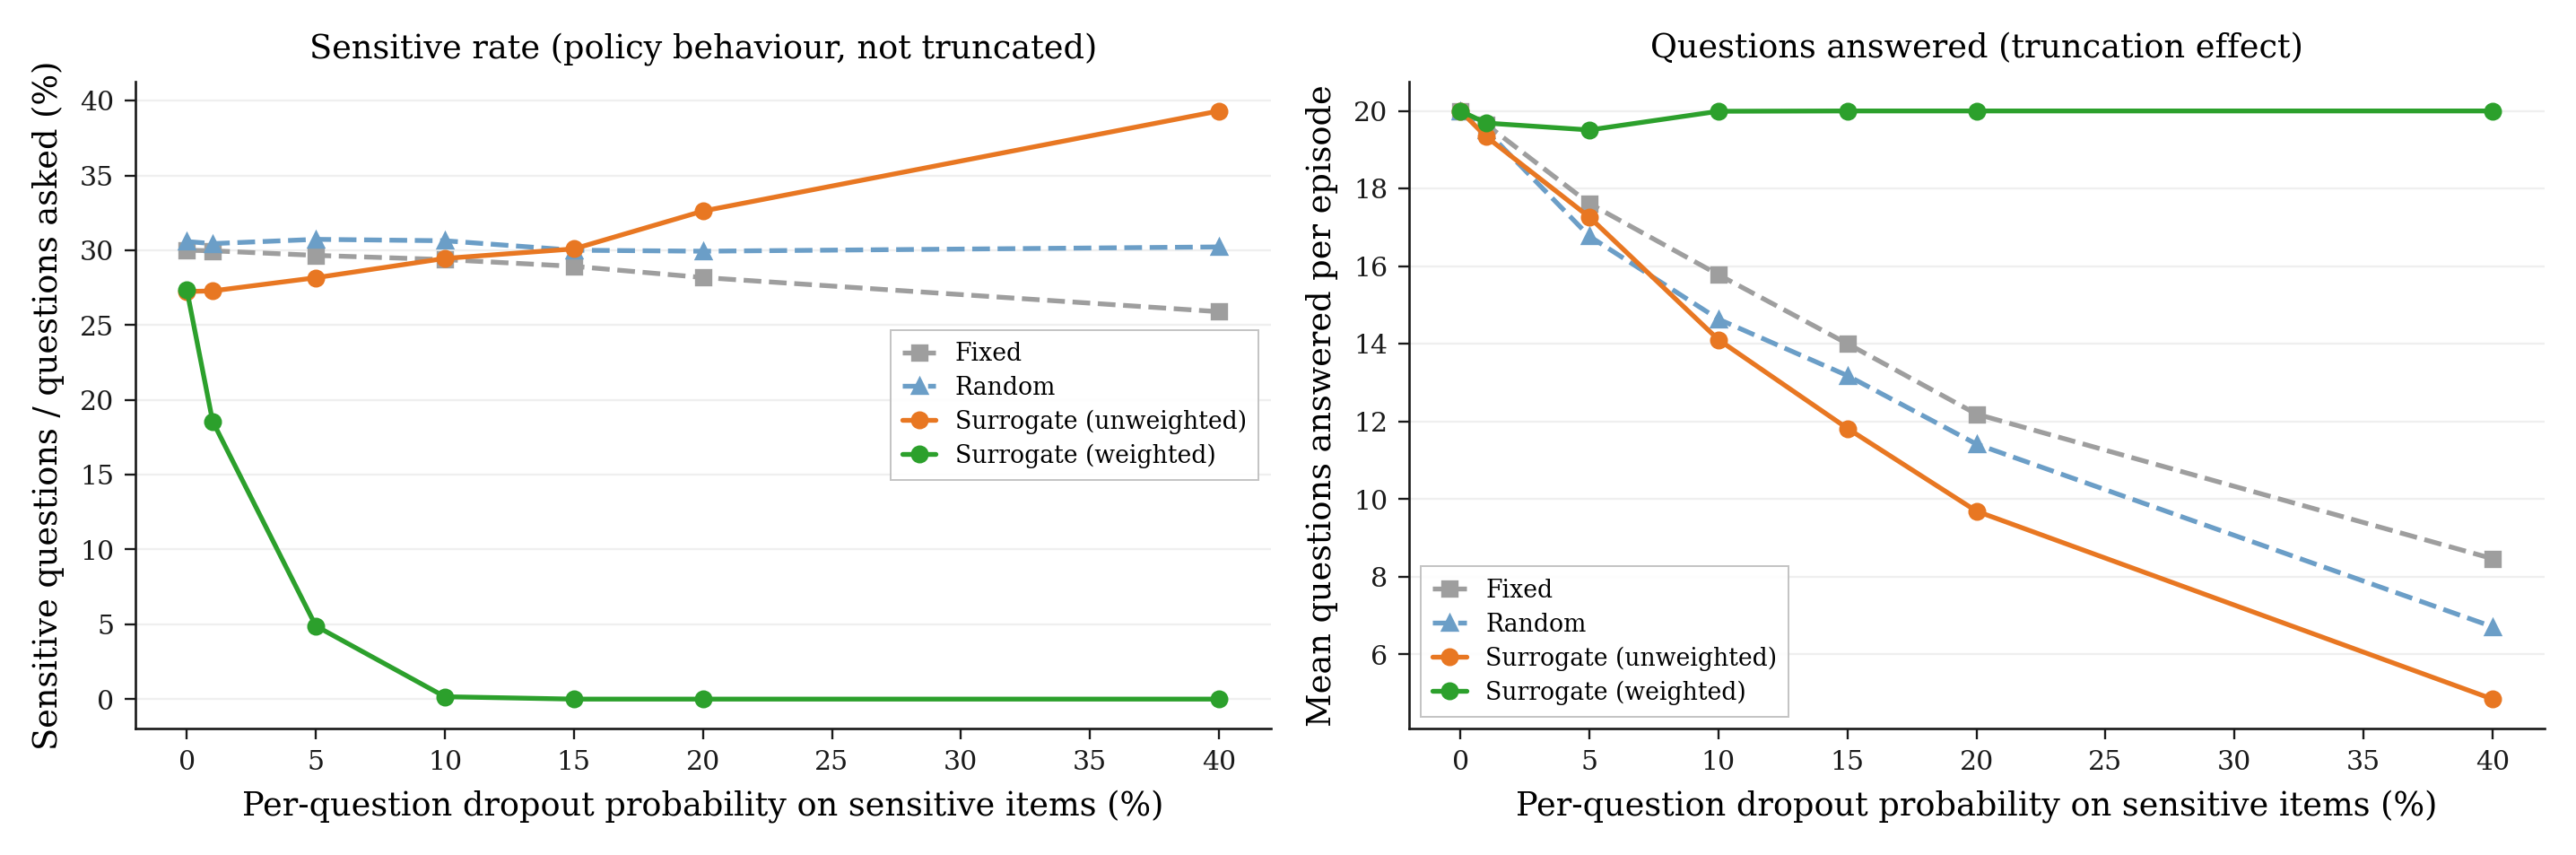

In [ ]:
# Figure 1c: Sensitive rate + questions answered vs dropout probability
#
# Sensitive RATE = mean_sensitive_asked / mean_n_asked is the fraction of
# presented questions that were sensitive.  This is unconfounded by dropout
# truncation: a policy that triggers early dropout will show a low raw
# sensitive COUNT (users left before more could be asked), but its RATE
# reveals the true selection behaviour.
#
# Mean answered (right) shows the truncation effect directly.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: sensitive rate
ax = axes[0]
series = sweep_series(dropout_sweep, "sensitive_rate")
for policy, (xs, ys) in series.items():
    s = POLICY_STYLE[policy]
    ax.plot(np.array(xs) * 100, np.array(ys) * 100,
            color=s["color"], ls=s["ls"], marker=s["marker"],
            markersize=5, linewidth=1.6, label=s["label"])
ax.set_xlabel("Per-question dropout probability on sensitive items (%)")
ax.set_ylabel("Sensitive questions / questions asked (%)")
ax.set_title("Sensitive rate (policy behaviour, not truncated)")
style_ax(ax, grid_axis="y")
ax.legend(fontsize=8)

# Right: mean questions answered (shows truncation effect)
ax = axes[1]
series = sweep_series(dropout_sweep, "mean_n_answered")
for policy, (xs, ys) in series.items():
    s = POLICY_STYLE[policy]
    ax.plot(np.array(xs) * 100, ys,
            color=s["color"], ls=s["ls"], marker=s["marker"],
            markersize=5, linewidth=1.6, label=s["label"])
ax.set_xlabel("Per-question dropout probability on sensitive items (%)")
ax.set_ylabel("Mean # questions answered per episode")
ax.set_title("Questions answered (truncation effect)")
style_ax(ax, grid_axis="y")
ax.legend(fontsize=8)

plt.tight_layout()
# save(fig, "fig_sensitive_rate_vs_dropout")  # uncomment to export
plt.show()

---
## 2 — Sensitive fraction sweep

**Run first:**
```bash
python -m experiments.sweep --param sensitive-frac --values 0.1 0.2 0.3 0.4 0.5 --no-myopic
```

In [41]:
sfrac_sweep = load_sweep("sensitive_frac")

Loading: 20260428_164858_sweep_sensitive_frac.json


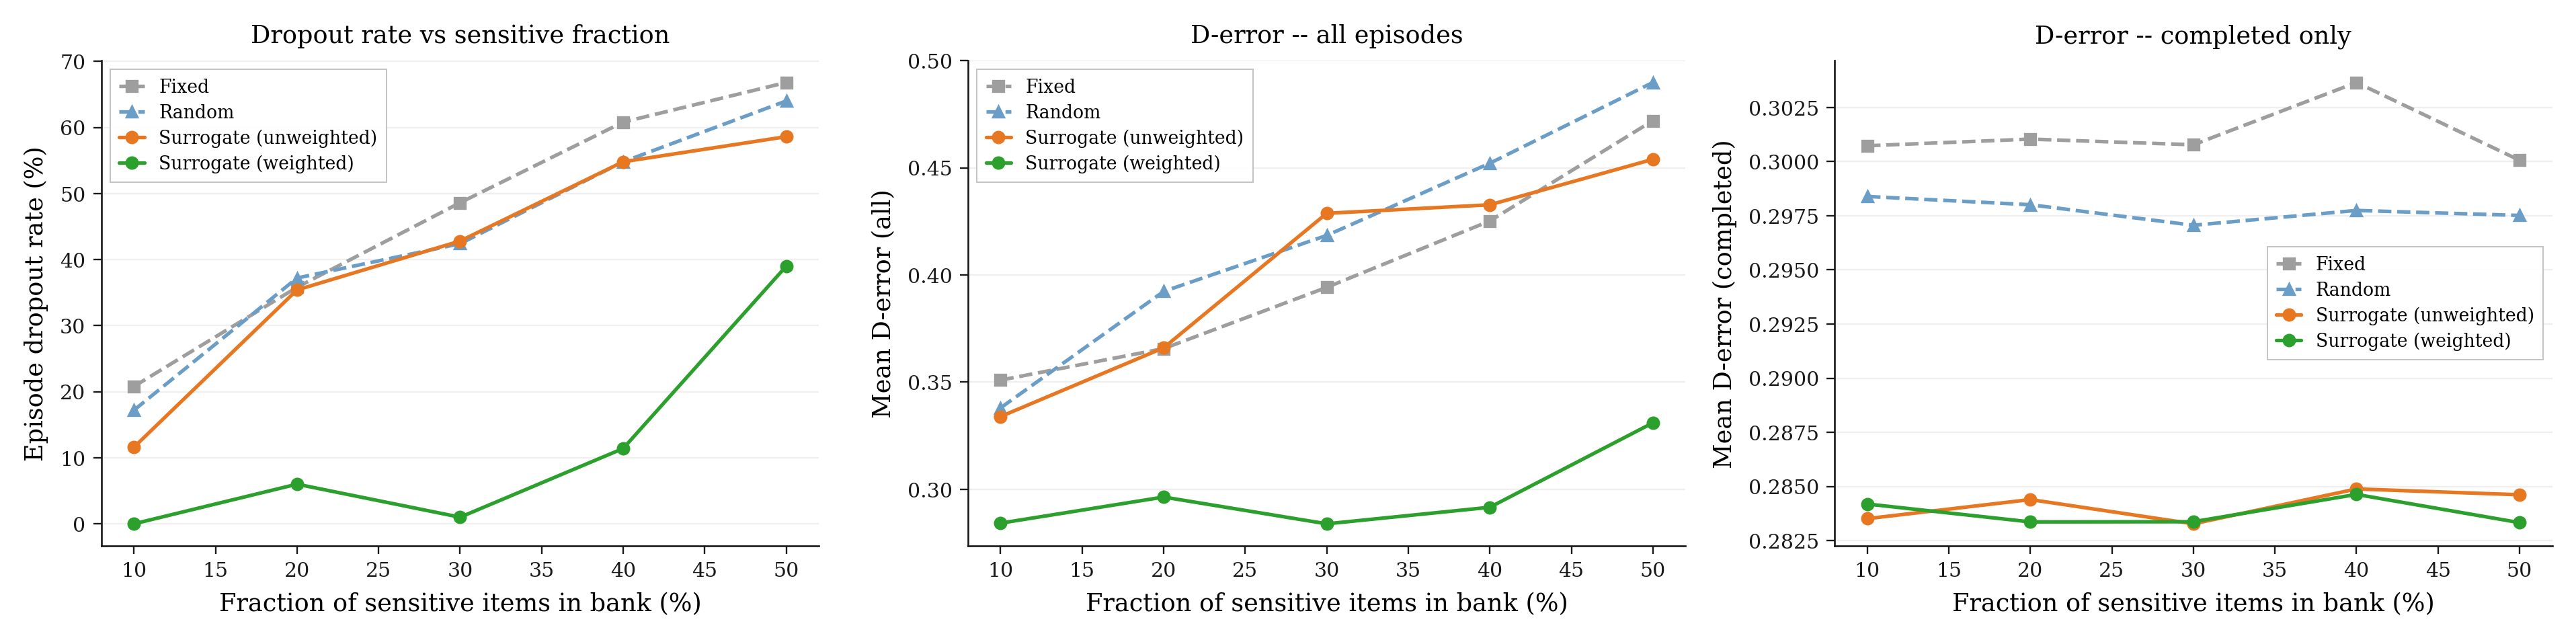

In [42]:
# Figure 2a: Sensitive fraction sweep
# Left:   Dropout rate vs sensitive fraction (primary safety outcome).
# Middle: D-error (all episodes) -- confounded when dropout differs across policies.
# Right:  D-error (completed only) -- isolates genuine information quality.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, ylabel, title in [
    (axes[0], "dropout_rate",                  "Episode dropout rate (%)",   "Dropout rate vs sensitive fraction"),
    (axes[1], "mean_final_d_error",            "Mean D-error (all)",         "D-error -- all episodes"),
    (axes[2], "mean_final_d_error_completed",  "Mean D-error (completed)",   "D-error -- completed only"),
]:
    series = sweep_series(sfrac_sweep, metric)
    for policy, (xs, ys) in series.items():
        s = POLICY_STYLE[policy]
        yvals = [v * 100 for v in ys] if metric == "dropout_rate" else ys
        ax.plot([x * 100 for x in xs], yvals,
                color=s["color"], ls=s["ls"], marker=s["marker"],
                markersize=5, linewidth=1.6, label=s["label"])
    ax.set_xlabel("Fraction of sensitive items in bank (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    style_ax(ax, grid_axis="y")
    ax.legend(fontsize=8)

plt.tight_layout()
# save(fig, "fig_sensitive_frac_sweep")  # uncomment to export
plt.show()

---
## 3 — Horizon sweep

**Run first:**
```bash
# 2D
python -m experiments.sweep --param horizon --values 4 8 12 16 20 --dropout 0.10 --no-myopic
# 6D
python -m experiments.sweep --param horizon --values 6 12 18 24 36 --dim 6 --dropout 0.10 --no-myopic
```

If you ran both, load whichever is most relevant below.

In [43]:
horizon_sweep = load_sweep("horizon")

Loading: 20260428_170552_sweep_horizon.json


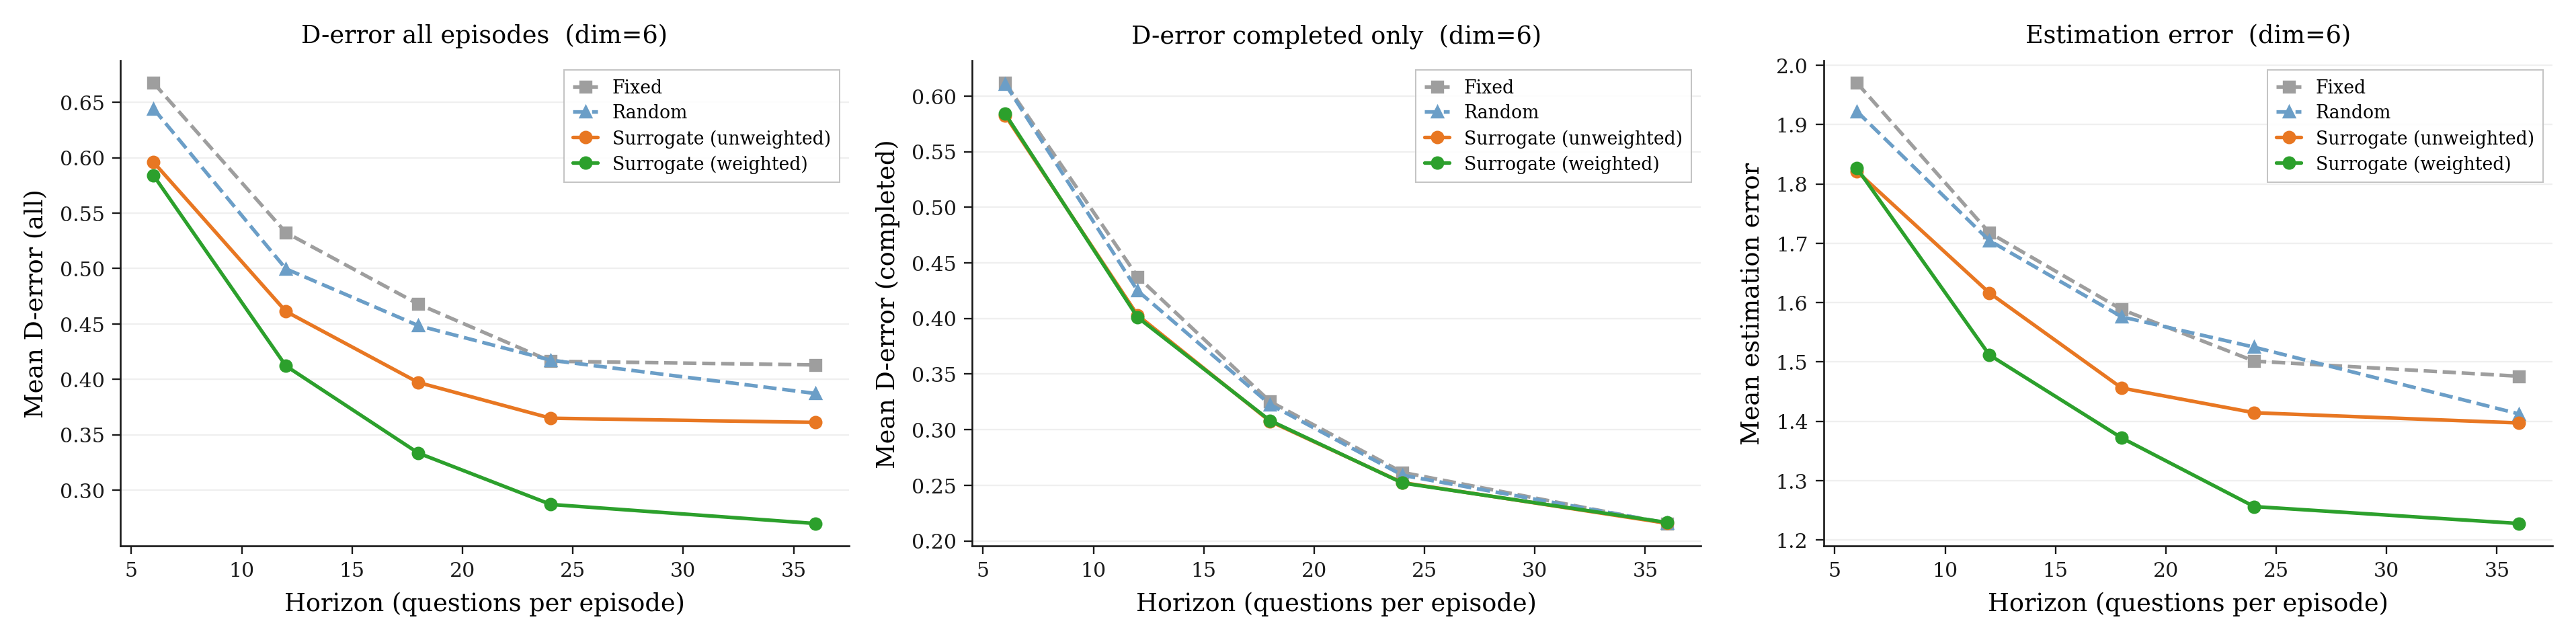

In [44]:
# Figure 3: Horizon sweep
# At short horizons, policies with high dropout ask fewer questions AND
# end with less-refined posteriors -- conflating two effects.
# D-error (completed only) shows what the posterior looks like for users
# who actually finished, decoupling information quality from dropout rate.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

dim = horizon_sweep["fixed_config"].get("dim", "?")

for ax, metric, ylabel, title in [
    (axes[0], "mean_final_d_error",           "Mean D-error (all)",
     f"D-error all episodes  (dim={dim})"),
    (axes[1], "mean_final_d_error_completed",  "Mean D-error (completed)",
     f"D-error completed only  (dim={dim})"),
    (axes[2], "mean_estimation_error",         "Mean estimation error",
     f"Estimation error  (dim={dim})"),
]:
    series = sweep_series(horizon_sweep, metric)
    for policy, (xs, ys) in series.items():
        s = POLICY_STYLE[policy]
        ax.plot(xs, ys,
                color=s["color"], ls=s["ls"], marker=s["marker"],
                markersize=5, linewidth=1.6, label=s["label"])
    ax.set_xlabel("Horizon (questions per episode)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    style_ax(ax, grid_axis="y")
    ax.legend(fontsize=8)

plt.tight_layout()
# save(fig, "fig_horizon_sweep")  # uncomment to export
plt.show()

---
## 4 — Dimension sweep

**Run first:**
```bash
python -m experiments.sweep --param dim --values 2 4 6 8 --horizon 20 --dropout 0.10 --items 50 --no-myopic
```

In [45]:
dim_sweep = load_sweep("dim")

Loading: 20260429_084834_sweep_dim.json


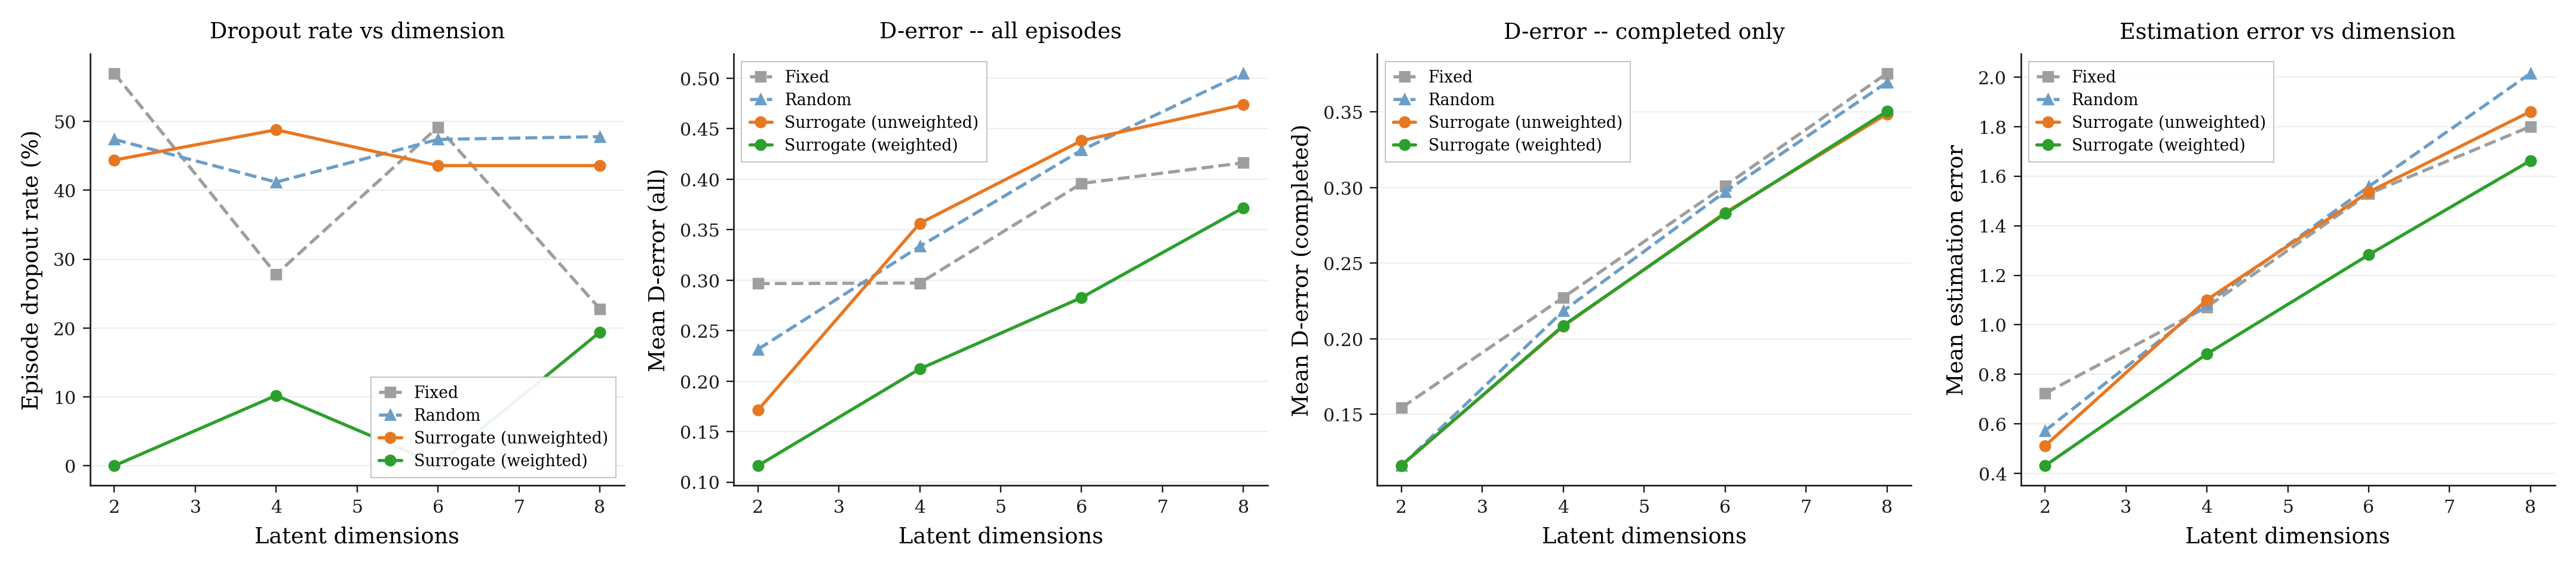

In [46]:
# Figure 4: Dimension sweep
# Higher dimensions require more questions to achieve the same coverage.
# At fixed horizon, higher-dim runs have more dropout, so raw D-error is
# inflated for unsafe policies. D-error (completed only) separates the effects.
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, metric, ylabel, title in [
    (axes[0], "dropout_rate",                  "Episode dropout rate (%)",  "Dropout rate vs dimension"),
    (axes[1], "mean_final_d_error",            "Mean D-error (all)",        "D-error -- all episodes"),
    (axes[2], "mean_final_d_error_completed",  "Mean D-error (completed)",  "D-error -- completed only"),
    (axes[3], "mean_estimation_error",         "Mean estimation error",     "Estimation error vs dimension"),
]:
    series = sweep_series(dim_sweep, metric)
    for policy, (xs, ys) in series.items():
        s = POLICY_STYLE[policy]
        yvals = [v * 100 for v in ys] if metric == "dropout_rate" else ys
        ax.plot(xs, yvals,
                color=s["color"], ls=s["ls"], marker=s["marker"],
                markersize=5, linewidth=1.6, label=s["label"])
    ax.set_xlabel("Latent dimensions")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    style_ax(ax, grid_axis="y")
    ax.legend(fontsize=8)

plt.tight_layout()
# save(fig, "fig_dimension_sweep")  # uncomment to export
plt.show()

---
## 5 — Single run summary

Quick bar chart of all metrics for a single run — useful for a first look at any new configuration.

In [47]:
run = load_run()

Loading: 20260429_085020_dim8_h20_p10_n500.json


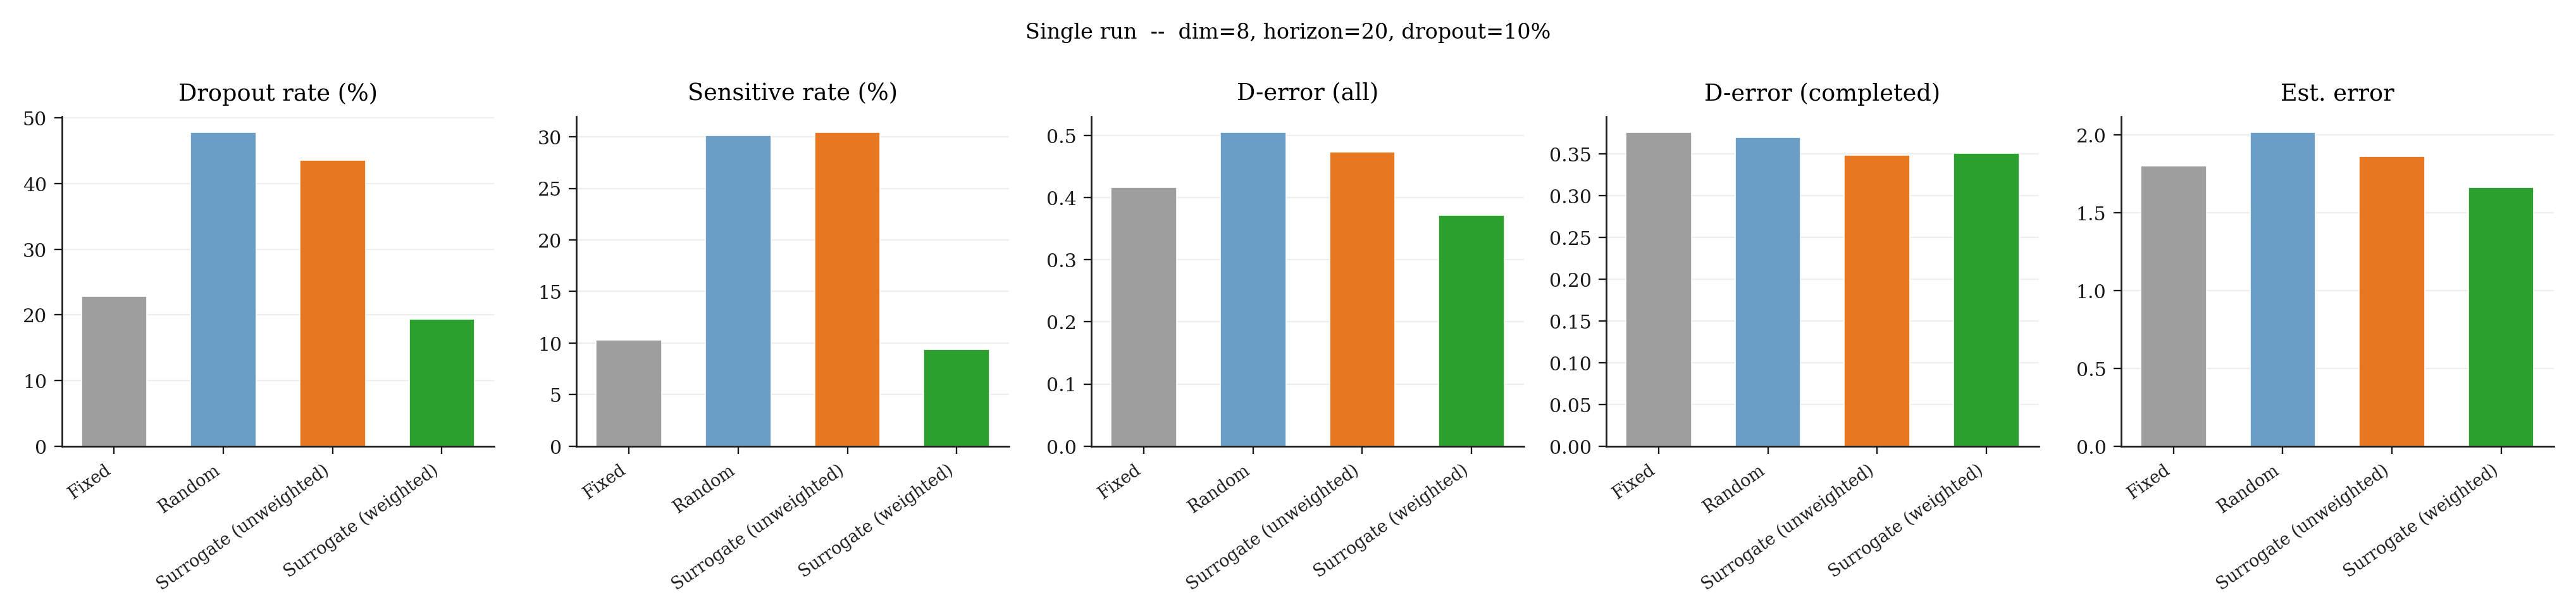

In [48]:
# Figure 5: Bar chart summary for one run
policies  = list(run["policies"].keys())
colors    = [POLICY_STYLE[p]["color"] for p in policies]
labels    = [POLICY_STYLE[p]["label"] for p in policies]
cfg       = run["config"]

metrics_to_plot = [
    ("dropout_rate",                  "Dropout rate",       True,  "%"),
    ("sensitive_rate",                "Sensitive rate",     True,  "%"),
    ("mean_final_d_error",            "D-error (all)",      False, ""),
    ("mean_final_d_error_completed",  "D-error (completed)",False, ""),
    ("mean_estimation_error",         "Est. error",         False, ""),
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(17, 4))
fig.suptitle(
    f"Single run  --  dim={cfg['dim']}, horizon={cfg['horizon']}, "
    f"dropout={cfg['p_dropout_sens']*100:.0f}%",
    fontsize=10,
)

x = np.arange(len(policies))
for ax, (metric, title, as_pct, unit) in zip(axes, metrics_to_plot):
    vals = []
    for p in policies:
        v = run["policies"][p].get(metric, float("nan"))
        vals.append(v * 100 if as_pct else v)
    ax.bar(x, vals, color=colors, width=0.6, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_title(title + (f" ({unit})" if unit else ""))
    style_ax(ax, grid_axis="y")

plt.tight_layout()
# save(fig, "fig_single_run_summary")  # uncomment to export
plt.show()

---
## Notes

_Record observations from the sweeps here._

### Dropout sweep

- 

### Sensitive fraction sweep

- 

### Horizon sweep

- 

### Dimension sweep

- 